### Note
This code has been adapted from [Brian's notebook](https://github.com/bglenardo/XeActivation/blob/main/MNRC%20Activation%20Calculations.ipynb). I made a few changes based on how I prefer to plot the data for my thesis.

In [1]:
import Activation
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import copy
import importlib
import h5py
import subprocess
import os
import time
importlib.reload(Activation)
plt.style.use('clarke-default')

### Load the MNRC neutron spectrum and the neutron interaction cross section data

In [2]:
nucdata = Activation.LoadAllData()
mnrcspec = Activation.LoadMNRCSpectrum()
# reactor was operating at 250 kW rather than 1 MW
mnrcspec['Flux'] = mnrcspec['Flux']*0.25

Isotope: C13	Reaction: ng
Isotope: Co59	Reaction: ng
Isotope: Cr50	Reaction: ng
Isotope: Cr54	Reaction: ng
Isotope: Fe54	Reaction: ng
Isotope: Fe58	Reaction: ng
Isotope: Mo100	Reaction: ng
Isotope: Mo92	Reaction: ng
Isotope: Mo98	Reaction: ng
Isotope: Ni58	Reaction: np
Isotope: Ni60	Reaction: np
Isotope: Ni62	Reaction: ng
Isotope: Ni64	Reaction: ng
Isotope: P31	Reaction: ng
Isotope: S34	Reaction: ng
Isotope: Si30	Reaction: ng
Error with TENDL
Isotope: Xe124	Reaction: inel
Isotope: Xe124	Reaction: ng
Isotope: Xe124	Reaction: nonel
Isotope: Xe124	Reaction: ntot
Isotope: Xe125	Reaction: ng
Isotope: Xe125	Reaction: ninel
Isotope: Xe125	Reaction: nonel
Isotope: Xe125	Reaction: ntot
Isotope: Xe126	Reaction: ng
Isotope: Xe126	Reaction: nonel
Isotope: Xe127	Reaction: ng
Isotope: Xe127	Reaction: nonel
Isotope: Xe128	Reaction: ng
Isotope: Xe128	Reaction: ng
Isotope: Xe128	Reaction: nonel
Isotope: Xe129	Reaction: n
Isotope: Xe129	Reaction: n
Isotope: Xe129	Reaction: n
Isotope: Xe129	Reaction: n
I

Text(0.5, 0, 'Energy [MeV]')

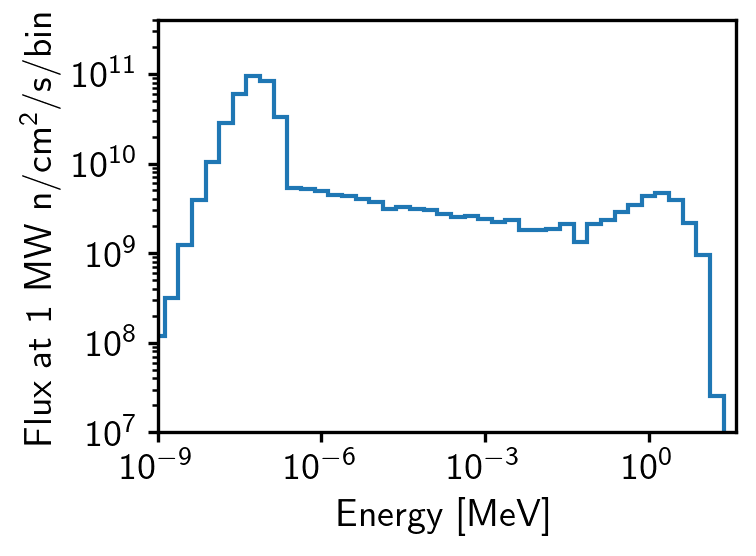

In [3]:
bin_centers = mnrcspec['Energy']
log_bin_centers = np.log10(bin_centers.values)
log_width = np.mean(np.diff(log_bin_centers))
log_bins = np.concatenate((log_bin_centers - log_width/2., np.array((log_bin_centers[-1] + log_width/2.,))))

fig, ax = plt.subplots(figsize=(4, 3))
# plot the nominal flux at 1 MW
ax.stairs(mnrcspec['Flux']/0.25, 10**log_bins, lw=1.5)
ax.set_xlim([1e-9, 4e1])
ax.set_ylim([1e7, 4e11])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel('Flux at 1~MW n/cm$^2$/s/bin')
ax.set_xlabel('Energy [MeV]')

{'ng':              1e-11     174.978
0     1.103040e-11  166.605000
1     1.216690e-11  158.633000
2     1.342060e-11  151.042000
3     1.480340e-11  143.814000
4     1.632870e-11  136.933000
...            ...         ...
1968  1.900000e+01    0.001249
1969  1.926810e+01    0.001259
1970  1.953990e+01    0.001269
1971  1.981560e+01    0.001280
1972  2.000000e+01    0.001286

[1973 rows x 2 columns]}


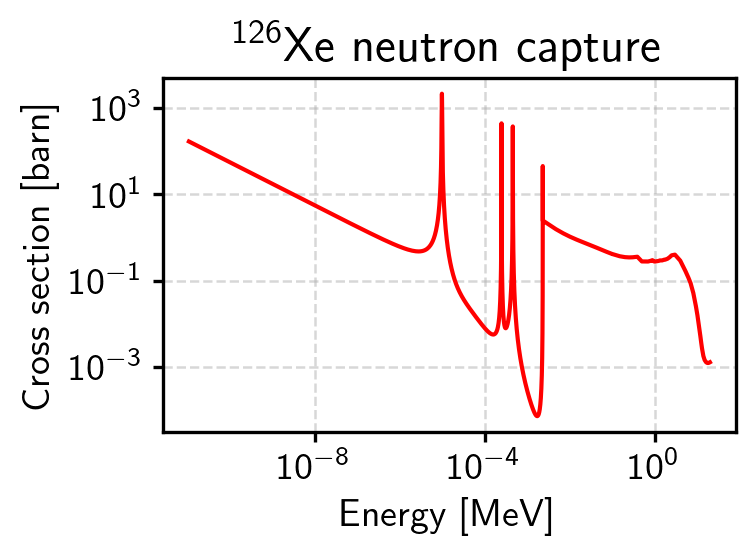

In [4]:
print(nucdata['Xe126'])

fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(nucdata['Xe126']['ng'].iloc[:,0], nucdata['Xe126']['ng'].iloc[:,1], '-r')

ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Energy [MeV]')
ax.set_ylabel('Cross section [barn]')
ax.set_title('$^{126}$Xe neutron capture')
ax.grid()

### Compute the expected Xe-127 activity based on the reactor spectrum and neutron-capture cross section

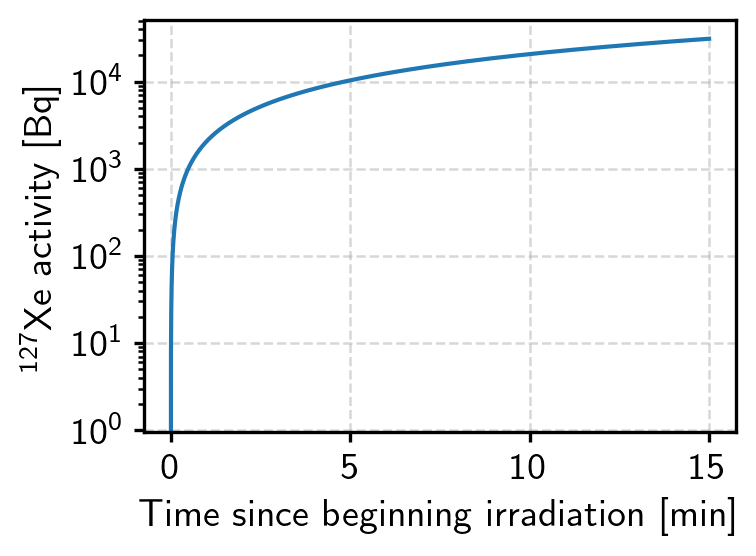

In [5]:
frac_126 = 0.00089 # natural abundance of xenon-126
M_xe = 131.293 # molar mass in g/mol
xenon_mass = 70. # grams
N_avo = 6.02e23 # Avogadro's number

N_126_0 = xenon_mass*frac_126*N_avo/M_xe
N_127_0 = 0.

T_half_127 = 36.3*3600*24 # half life in seconds
tau_127 = T_half_127/np.log(2) # lifetime in seconds

activation_rate, _ = Activation.InterpolateAndIntegrateAvg(nucdata['Xe126']['ng'], mnrcspec)

time_irr = np.linspace(0.,900.,20000)
dt = time_irr[1] - time_irr[0]
N_127 = np.zeros(len(time_irr))
N_126 = N_126_0*np.ones(len(time_irr))

for i in range(1, len(N_127)):
    N_126[i] = N_126[i-1] - N_126[i-1]*activation_rate*dt
    N_127[i] = N_127[i-1] + (-N_127[i-1]/tau_127 + N_126[i-1]*activation_rate)*dt

fig, ax = plt.subplots(figsize=(4, 3))
ax.semilogy(time_irr/60., N_127/tau_127)
ax.set_xlabel('Time since beginning irradiation [min]')
ax.set_ylabel('$^{127}$Xe activity [Bq]')
ax.grid()

### Load data on the isotopic composition of stainless steel

In [6]:
stainless_table = pd.read_csv('./Element tables - 316L Stainless.csv')
stainless_table['Daughter radiation'] = stainless_table['Daughter radiation'].astype(str)
stainless_table['Daughter decay product'] = stainless_table['Daughter decay product'].astype(str)
stainless_table.head(n=30)

,Element,Element fraction,A,Isotope fraction,Reaction,Capture daughter,Daughter halflife (s),Daughter radiation,Daughter energy (keV),Daughter decay product,DDP A
0,Fe,0.65545,54,0.05850,ng,55,8.609328e+07,EC,6.0,Mn,55.0
1,Fe,0.65545,56,0.91750,ng,57,inf,nan,0.0,nan,0.0
2,Fe,0.65545,57,0.02120,ng,58,inf,nan,0.0,nan,0.0
3,Fe,0.65545,58,0.00280,ng,59,3.853440e+06,B,1100.0,Co,59.0
4,N,0.00100,14,0.99600,ng,15,inf,nan,0.0,nan,0.0
5,N,0.00100,15,0.00400,ng,16,7.130000e+00,B,6000.0,O,16.0
6,Ni,0.12000,58,0.68077,np,58,6.122304e+06,EC,800.0,Co,58.0
7,Ni,0.12000,60,0.26223,np,60,1.662389e+08,B,1300.0,Co,60.0
8,Ni,0.12000,61,0.01140,ng,62,inf,nan,0.0,nan,0.0
9,Ni,0.12000,62,0.03635,ng,63,3.153600e+09,B,66.0,Cu,63.0


In [7]:
# N will store the number-of-atoms for each isotope of interest
NSteel = dict()
SpecActivitySteel = dict()
HalfLifeSteel = dict()

# How many atoms per gram of stainless steel?
ss316L_molarmass = np.sum(stainless_table['Element fraction']*stainless_table['A']*stainless_table['Isotope fraction'])
print('Molar mass of stainless steel: {} g/mol'.format(ss316L_molarmass))
ss316L_molperg = 1./ss316L_molarmass

Molar mass of stainless steel: 56.41755227999999 g/mol


In [8]:
for index, row in stainless_table.iterrows():

    if 'nan' in row['Daughter radiation']:
        continue

    if row['Daughter halflife (s)'] < 3600.:
        continue
    
    if row['Reaction'] == 'ng':
    
        isotope = '{}{}'.format(row['Element'],row['A'])
        daughter = '{}{}'.format(row['Element'],row['A']+1)
        print('Running calculation for {} (Daughter: {})'.format(isotope,daughter))

        NSteel[daughter] = np.zeros(len(time_irr))
        SpecActivitySteel[daughter] = np.zeros(len(time_irr))
    
        creation_int, bin_by_bin = Activation.InterpolateAndIntegrateAvg(nucdata[isotope]['ng'], mnrcspec)
    
        N_parent_0 = ss316L_molperg * N_avo * row['Isotope fraction'] * row['Element fraction']
    
        for i in range(1,len(time_irr)):
            term1 = -NSteel[daughter][i-1]/(row['Daughter halflife (s)']/np.log(2))
            term2 = N_parent_0 * creation_int
            NSteel[daughter][i] = NSteel[daughter][i-1] + dt * (term1 + term2)
            SpecActivitySteel[daughter][i] = NSteel[daughter][i] / (row['Daughter halflife (s)']/np.log(2))
    
    if row['Reaction'] == 'np':
        
        isotope = '{}{}'.format(row['Element'],row['A'])
        daughter = '{}{}'.format(row['Daughter decay product'],row['A'])
        print('Running calculation for {} (Daughter: {})'.format(isotope,daughter))

        NSteel[daughter] = np.zeros(len(time_irr))
        SpecActivitySteel[daughter] = np.zeros(len(time_irr))
    
        creation_int, bin_by_bin = Activation.InterpolateAndIntegrateAvg(nucdata[isotope]['np'], mnrcspec)
    
        N_parent_0 = ss316L_molperg * N_avo * row['Isotope fraction'] * row['Element fraction']
    
        for i in range(1,len(time_irr)):
            term1 = -NSteel[daughter][i-1]/(row['Daughter halflife (s)']/np.log(2))
            term2 = N_parent_0 * creation_int
            NSteel[daughter][i] = NSteel[daughter][i-1] + dt * (term1 + term2)
            SpecActivitySteel[daughter][i] = NSteel[daughter][i] / (row['Daughter halflife (s)']/np.log(2))

    HalfLifeSteel[daughter] = row['Daughter halflife (s)']

Running calculation for Fe54 (Daughter: Fe55)
Running calculation for Fe58 (Daughter: Fe59)
Running calculation for Ni58 (Daughter: Co58)
Running calculation for Ni60 (Daughter: Co60)
Running calculation for Ni62 (Daughter: Ni63)
Running calculation for Ni64 (Daughter: Ni65)
Running calculation for Mo92 (Daughter: Mo93)
Running calculation for Mo98 (Daughter: Mo99)
Running calculation for Cr50 (Daughter: Cr51)
Running calculation for S34 (Daughter: S35)
Running calculation for P31 (Daughter: P32)
Running calculation for Si30 (Daughter: Si31)
Running calculation for C13 (Daughter: C14)
Running calculation for Co59 (Daughter: Co60)


### Plot expected number of atoms and activity in stainless steel

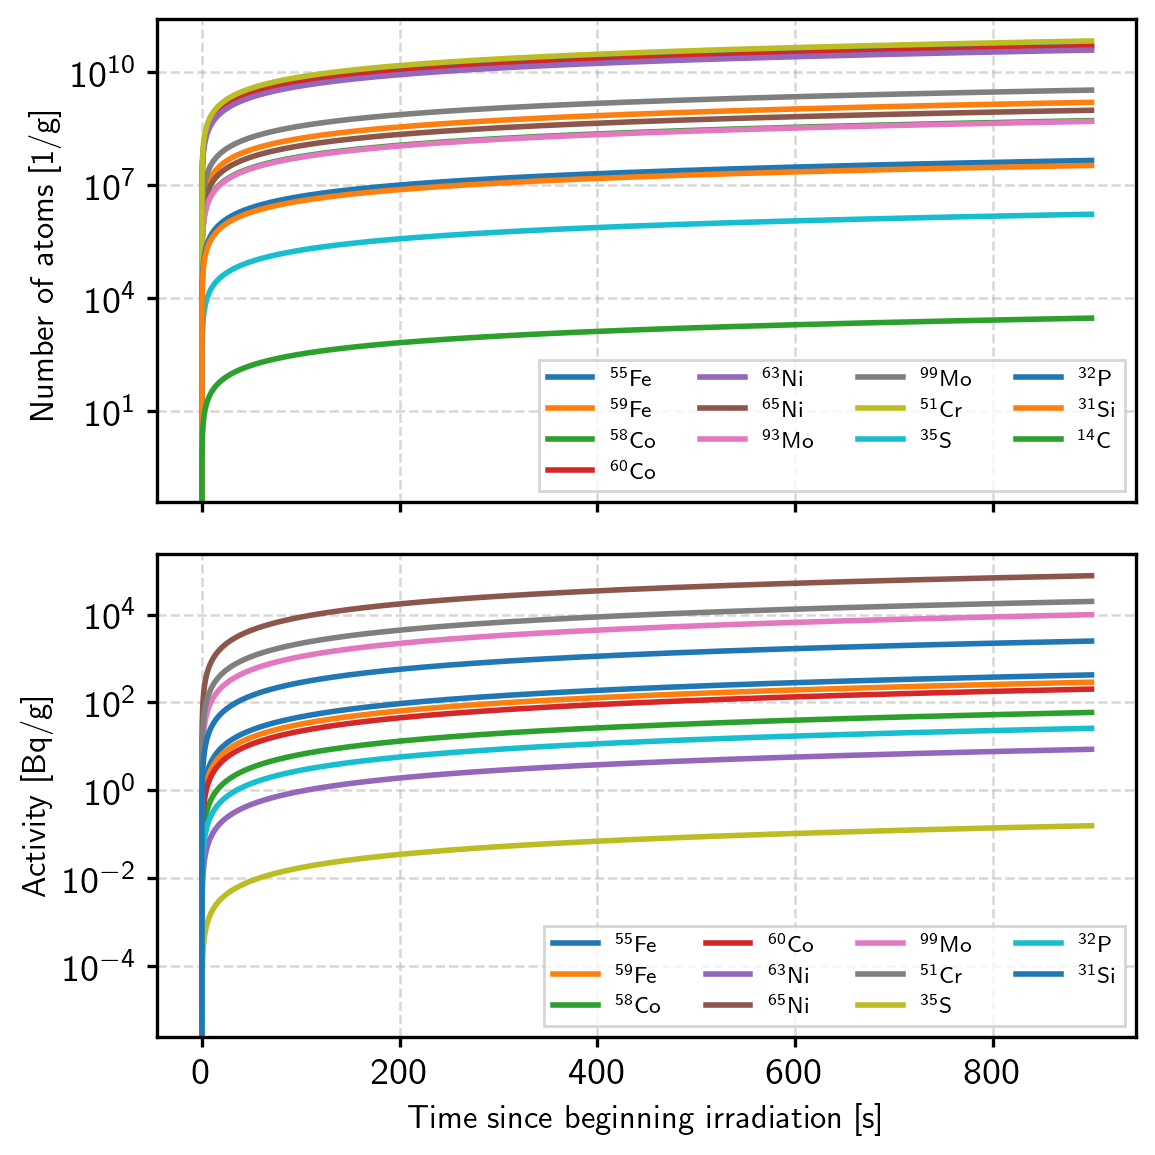

In [9]:
fig, ax = plt.subplots(2, figsize=(6, 6), sharex=True)

for isotope in NSteel.keys():
    ax[0].semilogy(time_irr, NSteel[isotope], lw=2, label='$^{' + isotope[-2:] + '}$' + isotope[:-2])
    if np.max(SpecActivitySteel[isotope]) < 0.1:
        continue
    ax[1].semilogy(time_irr, SpecActivitySteel[isotope], lw=2, label='$^{' + isotope[-2:] + '}$' + isotope[:-2])

ax[0].legend(fontsize=8, ncol=4)
ax[1].legend(fontsize=8, ncol=4)
ax[1].set_xlabel('Time since beginning irradiation [s]', fontsize=12)
ax[0].set_ylabel('Number of atoms [1/g]', fontsize=12)
ax[1].set_ylabel('Activity [Bq/g]', fontsize=12)
ax[0].grid()
ax[1].grid()

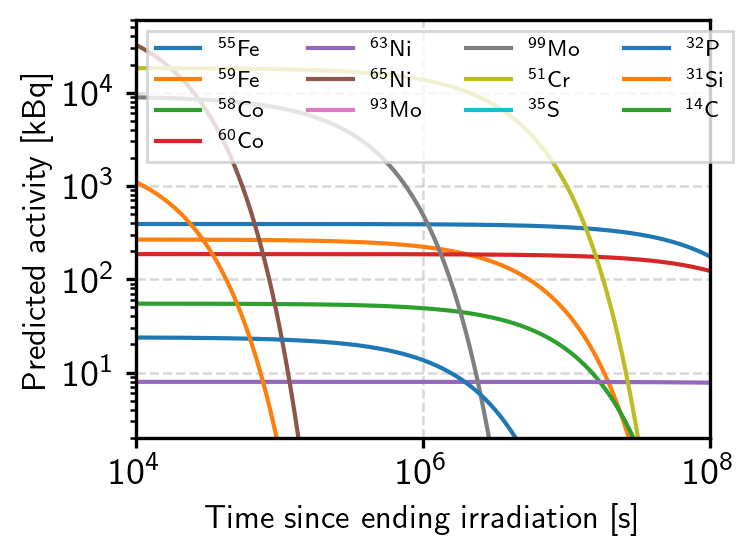

In [10]:
times = np.logspace(1, 8, 100000)
# colors = [plt.get_cmap('rainbow',13)(i) for i in range(13)]
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']*2

bottle_mass = 924. # grams
kBq_per_uCi = 37.
Bq_per_kBq = 1e3
prediction_scale = 0.21
assay_error = 0.5

# plot with all isotopes and no empirical scaling
fig, ax = plt.subplots(figsize=(4, 3))
for i,isotope in enumerate(NSteel.keys()):
    ax.loglog(times, bottle_mass*np.max(SpecActivitySteel[isotope])*np.exp(-times*np.log(2)\
              /HalfLifeSteel[isotope])/Bq_per_kBq, \
              lw=1.5, label='$^{' + isotope[-2:] + '}$' + isotope[:-2], color=colors[i])

ax.legend(fontsize=8, ncol=4)
ax.set_ylim([2e0, 6e4])
ax.set_xlim([1e4, 1e8])
ax.set_xlabel('Time since ending irradiation [s]', fontsize=12)
ax.set_ylabel('Predicted activity [kBq]', fontsize=12)
ax.grid()

### Scale the activity to the assay data to compute the neutron flux

/var/tmp/hardy27/ipykernel_220478/1864737420.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  assay_results_run = pd.concat([assay_results_run, pd.DataFrame({
/var/tmp/hardy27/ipykernel_220478/1864737420.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  assay_results_su = pd.concat([assay_results_su, pd.DataFrame({
/g/g92/hardy27/xe127-env/lib/python3.9/site-packages/matplotlib/cbook.py:1762: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError i

  Isotope  Assay Result  Time
0    Cr51        80.000   9.0
1    Co58         0.306   9.0
2    Fe59         1.640   9.0
3    Co60         2.400   9.0
  Isotope  Assay Result  Time
0    Cr51       45.7400  25.0
1    Co58        0.2189  25.0
2    Fe59        1.0860  25.0
3    Co60        2.0000  25.0


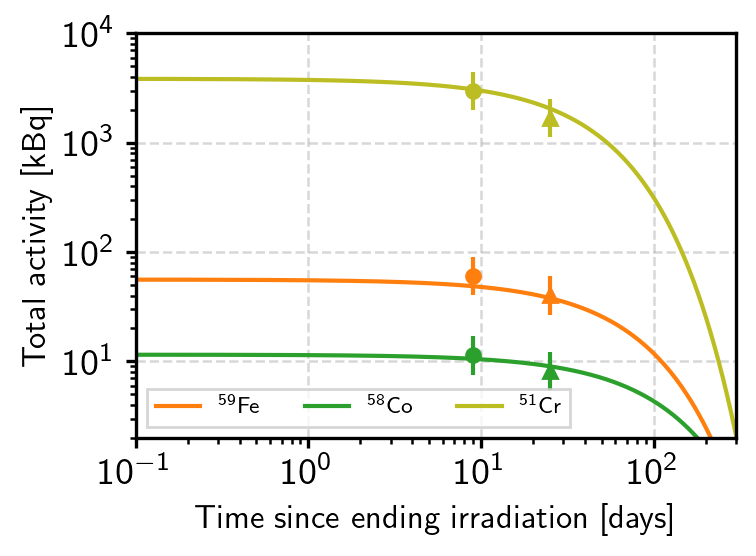

In [11]:
# assay results are reported in uCi
assay_results_run = pd.DataFrame(columns=['Isotope','Assay Result','Time'])
assay_results_run = pd.concat([assay_results_run, pd.DataFrame({
    'Isotope': ['Cr51', 'Co58', 'Fe59', 'Co60'],
    'Assay Result': [80., 0.306, 1.64, 2.4],
    'Time': [9.]*4
})], ignore_index=True)
print(assay_results_run.head())

assay_results_su = pd.DataFrame(columns=['Isotope','Assay Result','Time'])
assay_results_su = pd.concat([assay_results_su, pd.DataFrame({
    'Isotope': ['Cr51', 'Co58', 'Fe59', 'Co60'],
    'Assay Result': [45.74, 0.2189, 1.086, 2.0],
    'Time': [25.]*4
})], ignore_index=True)
print(assay_results_su.head())

# plot with the scaling to the three measured activities
fig, ax = plt.subplots(figsize=(4, 3))
for i,isotope in enumerate(NSteel.keys()):
    if 'Co58' not in isotope and \
       'Cr51' not in isotope and \
       'Fe59' not in isotope:
        continue

    ax.loglog(times/3600./24., bottle_mass*np.max(SpecActivitySteel[isotope])*np.exp(-times*np.log(2)\
              /HalfLifeSteel[isotope])/Bq_per_kBq*prediction_scale, \
              lw=1.5, label='$^{' + isotope[-2:] + '}$' + isotope[:-2], color=colors[i])
    
    assay_run_mask = (assay_results_run['Isotope']==isotope)
    assay_su_mask = (assay_results_su['Isotope']==isotope)
    
    if len(assay_results_run['Assay Result'].loc[assay_run_mask])>0:
        ax.errorbar(assay_results_run['Time'].loc[assay_run_mask],assay_results_run['Assay Result'].loc[assay_run_mask]*kBq_per_uCi,\
                    yerr=[ assay_results_run['Assay Result'].loc[assay_run_mask]*(1.-1./(1.+assay_error))*kBq_per_uCi,\
                           assay_results_run['Assay Result'].loc[assay_run_mask]*assay_error*kBq_per_uCi ],\
                    fmt='o',color=colors[i],markersize=5)
    if len(assay_results_su['Assay Result'].loc[assay_su_mask])>0:
        ax.errorbar(assay_results_su['Time'].loc[assay_su_mask],assay_results_su['Assay Result'].loc[assay_su_mask]*kBq_per_uCi,\
                    yerr=[ assay_results_su['Assay Result'].loc[assay_su_mask]*(1.-1./(1.+assay_error))*kBq_per_uCi,\
                           assay_results_su['Assay Result'].loc[assay_su_mask]*assay_error*kBq_per_uCi ],\
                    fmt='^',color=colors[i],markersize=5)

ax.legend(fontsize=8, ncol=4)
ax.set_ylim([2e0, 1e4])
ax.set_xlim([1e-1, 3e2])
ax.set_xlabel('Time since ending irradiation [days]', fontsize=12)
ax.set_ylabel('Total activity [kBq]', fontsize=12)
ax.grid()

### Repeat the process for the xenon in the cylinder

In [ ]:
xe_table = pd.read_csv('./Element tables - natXe.csv')
xe_table['Daughter radiation'] = xe_table['Daughter radiation'].astype(str)
xe_table['Daughter decay product'] = xe_table['Daughter decay product'].astype(str)
# Replace the Xe-137 info with Cs-137, which will stick around after all the Xe-137 decays quickly away.
xe_table.loc[8, 'Daughter halflife (s)'] = 949232333
xe_table.head(n=len(xe_table))

,Element,Element fraction,A,Isotope fraction,Capture daughter,Daughter halflife (s),Daughter radiation,Daughter energy (keV),Daughter decay product,DDP A
0,Xe,1,124,0.00095,125,60840.0,EC,300,I,125
1,Xe,1,126,0.00089,127,3140208.0,EC,400,I,127
2,Xe,1,128,0.01910,129,inf,nan,0,nan,0
3,Xe,1,129,0.26401,130,inf,nan,0,nan,0
4,Xe,1,130,0.04071,131,inf,nan,0,nan,0
5,Xe,1,131,0.21232,132,inf,nan,0,nan,0
6,Xe,1,132,0.26909,133,453340.8,B,80,Cs,133
7,Xe,1,134,0.10436,135,32904.0,B,0,Cs,135
8,Xe,1,136,0.08570,137,949232333.0,B,600,Cs,137


In [13]:
# N will store the number-of-atoms for each isotope of interest
NXe = dict()
SpecActivityXe = dict()
HalfLifeXe = dict()

# How many atoms per gram of stainless steel?
xe_molarmass = np.sum(xe_table['Element fraction'] * xe_table['A'] * xe_table['Isotope fraction'])
print('Molar mass of natural Xe gas: {} g/mol'.format(xe_molarmass))
xe_molperg = 1./xe_molarmass

Molar mass of natural Xe gas: 130.99757000000002 g/mol


In [ ]:
for index, row in xe_table.iterrows():

    if 'nan' in row['Daughter radiation']:
        continue
    if row['Daughter halflife (s)'] < 3600.:
        continue
 
    isotope = '{}{}'.format(row['Element'],row['A'])
    if row['A'] == 136:
            daughter = '{}{}'.format('Cs',row['A']+1)
    else:
            daughter = '{}{}'.format(row['Element'],row['A']+1)
    #if daughter == 'Cs137': continue
    print('Running calculation for {} (Daughter: {})'.format(isotope,daughter))
    
    NXe[daughter] = np.zeros(len(time_irr))
    SpecActivityXe[daughter] = np.zeros(len(time_irr))
    
    creation_int, bin_by_bin = Activation.InterpolateAndIntegrateAvg( nucdata[isotope]['ng'], mnrcspec )
    
    N_parent_0 = xe_molperg * N_avo * row['Isotope fraction'] * row['Element fraction']
    
    for i in range(1,len(time_irr)):
        term1 = -NXe[daughter][i-1]/(row['Daughter halflife (s)']/np.log(2))
        term2 = N_parent_0 * creation_int
        NXe[daughter][i] = NXe[daughter][i-1] + dt * (term1 + term2)
        SpecActivityXe[daughter][i] = NXe[daughter][i] / (row['Daughter halflife (s)']/np.log(2))

    HalfLifeXe[daughter] = row['Daughter halflife (s)']

Running calculation for Xe124 (Daughter: Xe125)
Running calculation for Xe126 (Daughter: Xe127)
Running calculation for Xe132 (Daughter: Xe133)
Running calculation for Xe134 (Daughter: Xe135)
Running calculation for Xe136 (Daughter: Cs137)


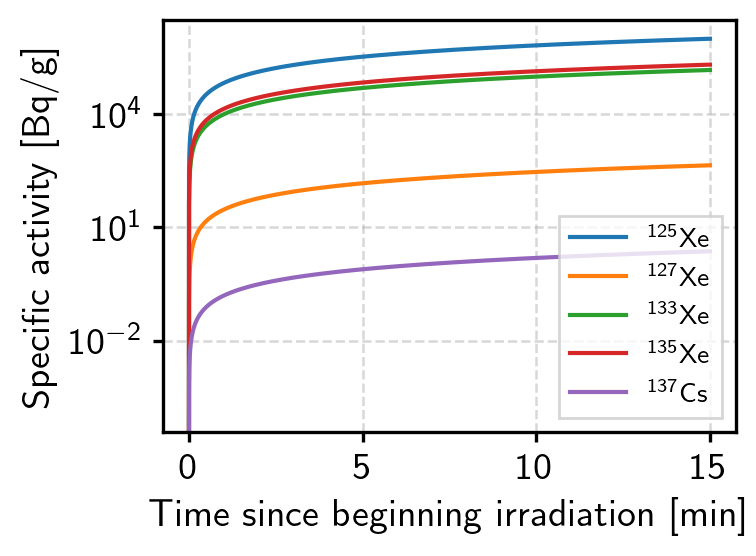

In [15]:
fig, ax = plt.subplots(figsize=(4, 3))

for isotope in NXe.keys():
    ax.semilogy(time_irr/60.,SpecActivityXe[isotope],lw=1.5,label='$^{' + isotope[-3:] + '}$' + isotope[:-3])

ax.legend(loc='lower right')
ax.set_xlabel('Time since beginning irradiation [min]')
ax.set_ylabel('Specific activity [Bq/g]')
ax.grid()

/g/g92/hardy27/xe127-env/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


creation_int_ng_excitation_128: 4.072531641107092e-15
creation_int_n_excitation_129: 1.1176051191165033e-15
creation_int_ng_excitation_130: 1.1690945471029592e-14
creation_int_n_excitation_131: 2.1271881008340336e-15
Activity Xe129m: 89.641 kBq, 2.423 uCi
Activity Xe131m: 369.130 kBq, 9.976 uCi


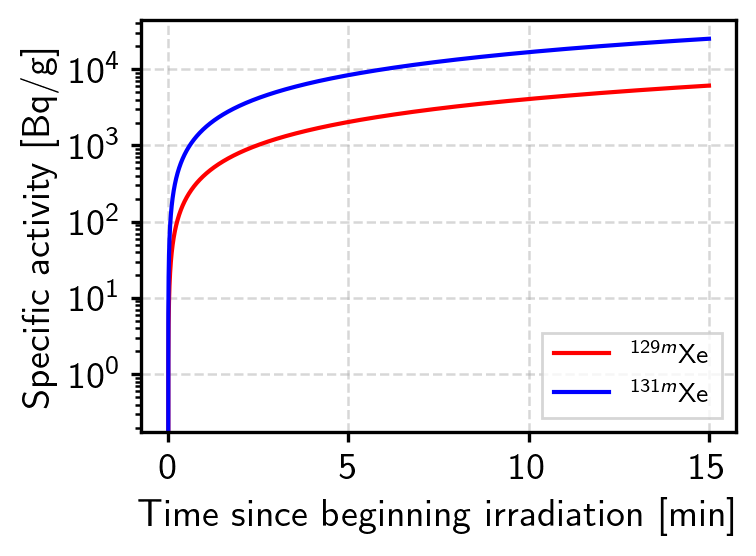

In [43]:
energy_values = np.logspace(-10.,2.,2000)

xe128_ng_excite = np.genfromtxt('CrossSections_copy/Xe128_ng_excite.txt')
xe129_n_excite = np.genfromtxt('CrossSections_copy/Xe129_n_excite.txt')
xe130_ng_excite = np.genfromtxt('CrossSections_copy/Xe130_ng_excite.txt')
xe131_n_excite = np.genfromtxt('CrossSections_copy/Xe131_n_excite.txt')

# TENDL neutron capture on Xe128
xe128_ng_excitation = {'energy':xe128_ng_excite[:,0],\
                       'cs':xe128_ng_excite[:,1]/1.e3}
xe128_ng_excitation = pd.DataFrame(xe128_ng_excitation)

# TENDL neutron inelastic to the level of interest
xe129_n_excitation = {'energy':xe129_n_excite[:,0],\
                      'cs':xe129_n_excite[:,1]/1.e3}
xe129_n_excitation = pd.DataFrame(xe129_n_excitation)

# TENDL neutron capture on Xe130
xe130_ng_excitation = {'energy':xe130_ng_excite[:,0],\
                       'cs':xe130_ng_excite[:,1]/1.e3}
xe130_ng_excitation = pd.DataFrame(xe130_ng_excitation)

# TENDL neutron inelastic to the level of interest
xe131_n_excitation = {'energy':xe131_n_excite[:,0],\
                       'cs':xe131_n_excite[:,1]/1.e3}
xe131_n_excitation = pd.DataFrame(xe131_n_excitation)

creation_int_ng_excitation_128,bin_by_bin_ng_excitation_128 = Activation.InterpolateAndIntegrateAvg2( xe128_ng_excitation, mnrcspec )
creation_int_n_excitation_129,bin_by_bin_n_excitation_129 = Activation.InterpolateAndIntegrateAvg2( xe129_n_excitation, mnrcspec )
creation_int_ng_excitation_130,bin_by_bin_ng_excitation_130 = Activation.InterpolateAndIntegrateAvg2( xe130_ng_excitation, mnrcspec )
creation_int_n_excitation_131,bin_by_bin_n_excitation_131 = Activation.InterpolateAndIntegrateAvg2( xe131_n_excitation, mnrcspec )
print('creation_int_ng_excitation_128: {}'.format(creation_int_ng_excitation_128))
print('creation_int_n_excitation_129: {}'.format(creation_int_n_excitation_129))
print('creation_int_ng_excitation_130: {}'.format(creation_int_ng_excitation_130))
print('creation_int_n_excitation_131: {}'.format(creation_int_n_excitation_131))

creation_int_ng_excitation_128,bin_by_bin_ng_excitation_128_2 = Activation.InterpolateAndIntegrateAvg( xe128_ng_excitation, mnrcspec )
creation_int_n_excitation_129,bin_by_bin_n_excitation_129_2 = Activation.InterpolateAndIntegrateAvg( xe129_n_excitation, mnrcspec )
creation_int_ng_excitation_130,bin_by_bin_ng_excitation_130_2 = Activation.InterpolateAndIntegrateAvg( xe130_ng_excitation, mnrcspec )
creation_int_n_excitation_131,bin_by_bin_n_excitation_131_2 = Activation.InterpolateAndIntegrateAvg( xe131_n_excitation, mnrcspec )

# compute number of Xe129m atoms over time
NXe['Xe129m'] = np.zeros(len(time_irr))
SpecActivityXe['Xe129m'] = np.zeros(len(time_irr))
N129_0 = xe_molperg*xe_table.loc[xe_table['A']==129, 'Isotope fraction'].iloc[0]*N_avo
N128_0 = xe_molperg*xe_table.loc[xe_table['A']==128, 'Isotope fraction'].iloc[0]*N_avo
N129m_0 = 0.
HalfLifeXe['Xe129m'] = 767232.
tau129m = HalfLifeXe['Xe129m']/np.log(2)
destruction_int = 0.

for i in range(1,len(time_irr)):
    term1 = -NXe['Xe129m'][i-1]/tau129m
    term2 = N129_0 * creation_int_n_excitation_129
    term3 = N128_0 * creation_int_ng_excitation_128
    term4 = -NXe['Xe129m'][i-1] * destruction_int
    NXe['Xe129m'][i] = NXe['Xe129m'][i-1] + dt * (term1 + term2 + term3 + term4)
    SpecActivityXe['Xe129m'][i] = NXe['Xe129m'][i]/tau129m

# compute number of Xe131m atoms over time
NXe['Xe131m'] = np.zeros(len(time_irr))
SpecActivityXe['Xe131m'] = np.zeros(len(time_irr))
N131_0 = xe_molperg*xe_table.loc[xe_table['A']==131, 'Isotope fraction'].iloc[0]*N_avo
N130_0 = xe_molperg*xe_table.loc[xe_table['A']==130, 'Isotope fraction'].iloc[0]*N_avo
N131m_0 = 0.
HalfLifeXe['Xe131m'] = 1022976.
tau131m = HalfLifeXe['Xe131m']/np.log(2)
destruction_int = 0.

for i in range(1,len(time_irr)):
    term1 = -NXe['Xe131m'][i-1]/tau131m
    term2 = N131_0 * creation_int_n_excitation_131
    term3 = N130_0 * creation_int_ng_excitation_130
    term4 = -NXe['Xe131m'][i-1] * destruction_int
    NXe['Xe131m'][i] = NXe['Xe131m'][i-1] + dt * (term1 + term2 + term3 + term4)
    SpecActivityXe['Xe131m'][i] = NXe['Xe131m'][i]/tau131m

print('Activity Xe129m: {:.3f} kBq, {:.3f} uCi'.format(np.max(SpecActivityXe['Xe129m'])*xenon_mass*prediction_scale/Bq_per_kBq, \
                                                       np.max(SpecActivityXe['Xe129m'])*xenon_mass*prediction_scale/kBq_per_uCi/Bq_per_kBq))
print('Activity Xe131m: {:.3f} kBq, {:.3f} uCi'.format(np.max(SpecActivityXe['Xe131m'])*xenon_mass*prediction_scale/Bq_per_kBq, \
                                                       np.max(SpecActivityXe['Xe131m'])*xenon_mass*prediction_scale/kBq_per_uCi/Bq_per_kBq))

fig, ax = plt.subplots(figsize=(4, 3))
ax.semilogy(time_irr/60.,NXe['Xe129m']/tau129m,'-r', label='$^{129m}$Xe')
ax.semilogy(time_irr/60.,NXe['Xe131m']/tau131m,'-b', label='$^{131m}$Xe')
ax.set_xlabel('Time since beginning irradiation [min]')
ax.set_ylabel('Specific activity [Bq/g]')
ax.legend()
ax.grid()

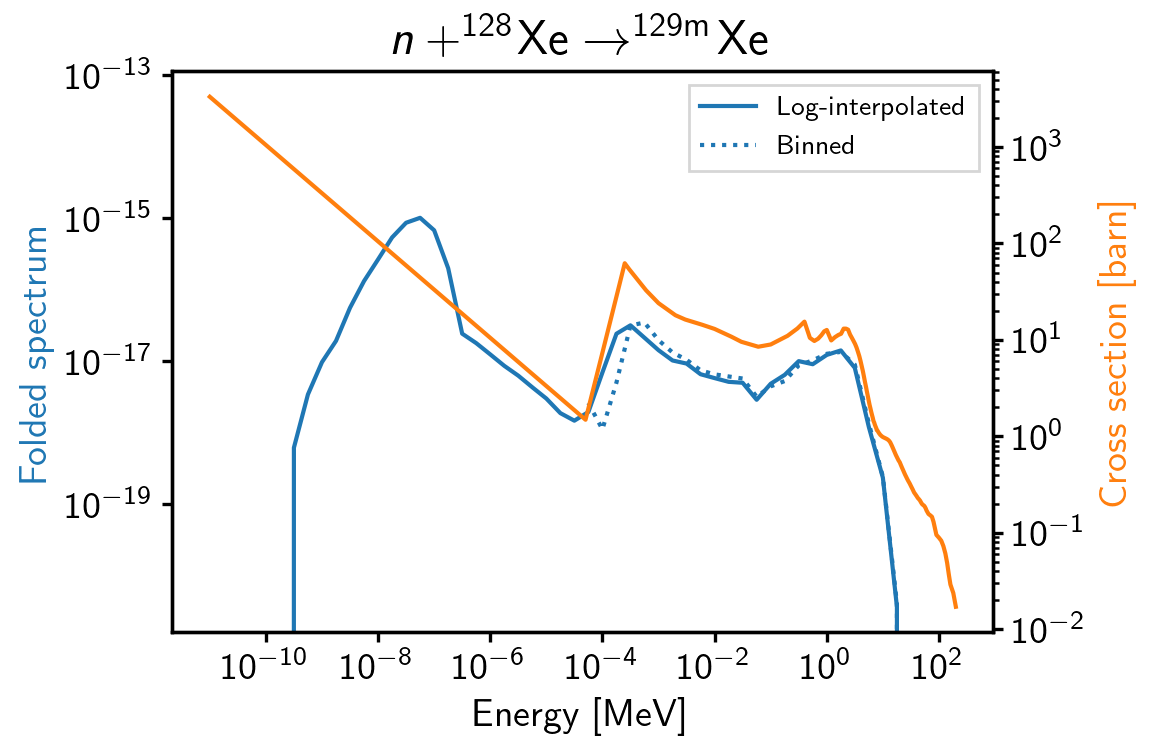

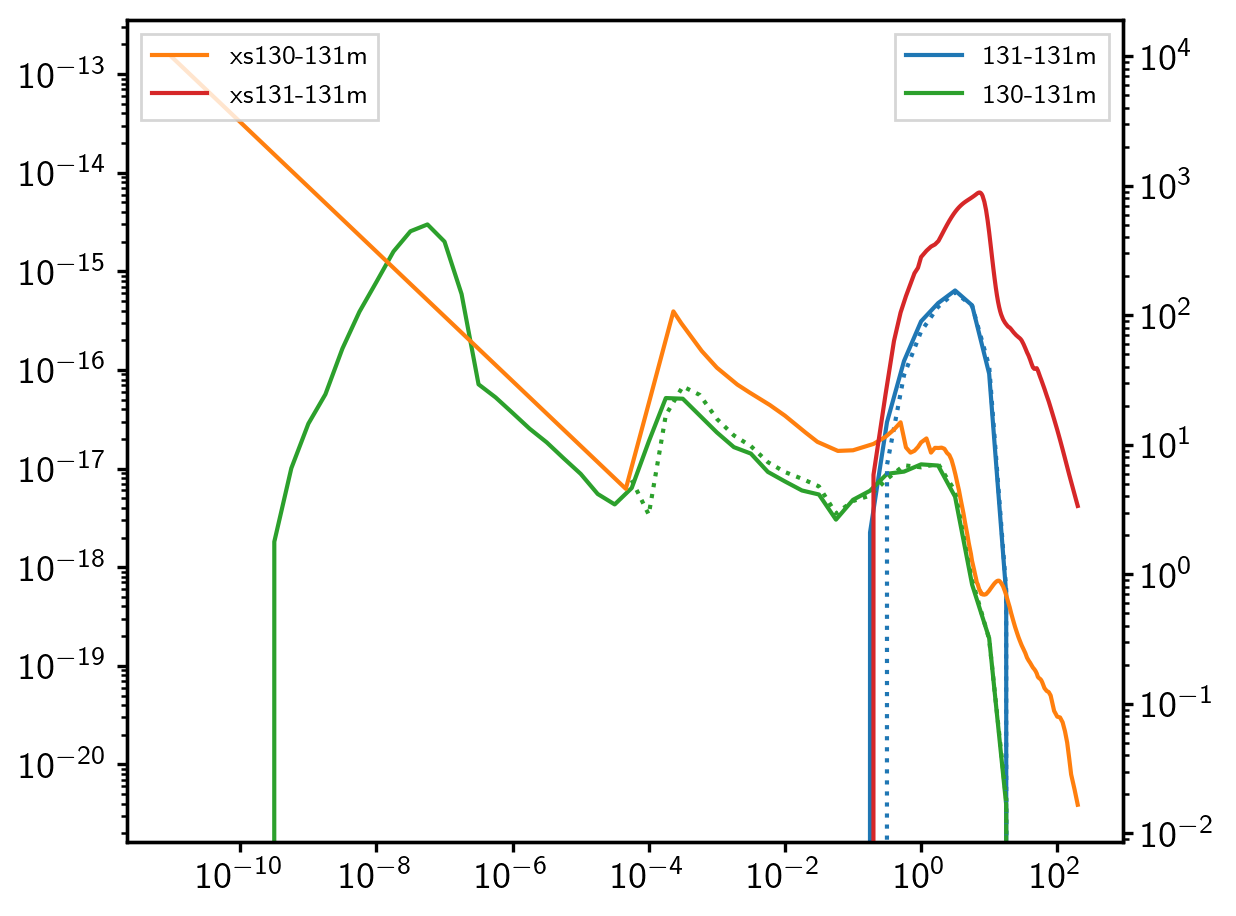

In [60]:
fig, ax = plt.subplots(figsize=(6,4))
# ax.loglog(mnrcspec['Energy'], bin_by_bin_n_excitation_129, color=colors[0], label='129-129m')
ax.loglog(mnrcspec['Energy'], bin_by_bin_ng_excitation_128, color=colors[0], label='Log-interpolated')
# ax.loglog(mnrcspec['Energy'], bin_by_bin_n_excitation_129_2, color=colors[0], ls=':')
ax.loglog(mnrcspec['Energy'], bin_by_bin_ng_excitation_128_2, color=colors[0], ls=':', label='Binned')
ax2 = ax.twinx()
ax2.loglog(xe128_ng_excite[:,0], xe128_ng_excite[:,1], color=colors[1])
# ax2.loglog(xe129_n_excite[:,0], xe129_n_excite[:,1], color=colors[3], label='xs129-129m')
ax.legend()
# ax2.legend(loc='upper left')
ax.set_ylabel('Folded spectrum', color=colors[0])
ax2.set_ylabel('Cross section [barn]', color=colors[1])
ax.set_xlabel('Energy [MeV]')
ax.set_title(r'$n + ^{128}\!\mathrm{Xe} \rightarrow ^\mathrm{129m}\!\mathrm{Xe}$')

fig, ax = plt.subplots()
ax.loglog(mnrcspec['Energy'], bin_by_bin_n_excitation_131, color=colors[0], label='131-131m')
ax.loglog(mnrcspec['Energy'], bin_by_bin_ng_excitation_130, color=colors[2], label='130-131m')
ax.loglog(mnrcspec['Energy'], bin_by_bin_n_excitation_131_2, color=colors[0], ls=':')
ax.loglog(mnrcspec['Energy'], bin_by_bin_ng_excitation_130_2, color=colors[2], ls=':')
ax2 = ax.twinx()
ax2.loglog(xe130_ng_excite[:,0], xe130_ng_excite[:,1], color=colors[1], label='xs130-131m')
ax2.loglog(xe131_n_excite[:,0], xe131_n_excite[:,1], color=colors[3], label='xs131-131m')
ax.legend()
ax2.legend(loc='upper left')

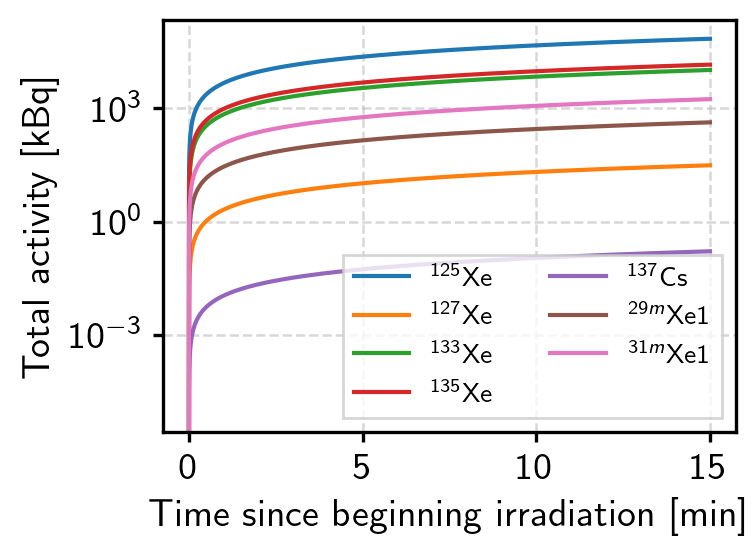

In [28]:
fig, ax = plt.subplots(figsize=(4, 3))

for isotope in NXe.keys():
    ax.semilogy(time_irr/60.,SpecActivityXe[isotope]*xenon_mass/Bq_per_kBq,lw=1.5,label='$^{' + isotope[-3:] + '}$' + isotope[:-3])

ax.legend(loc='lower right', ncol=2)
ax.set_xlabel('Time since beginning irradiation [min]')
ax.set_ylabel('Total activity [kBq]')
ax.grid()

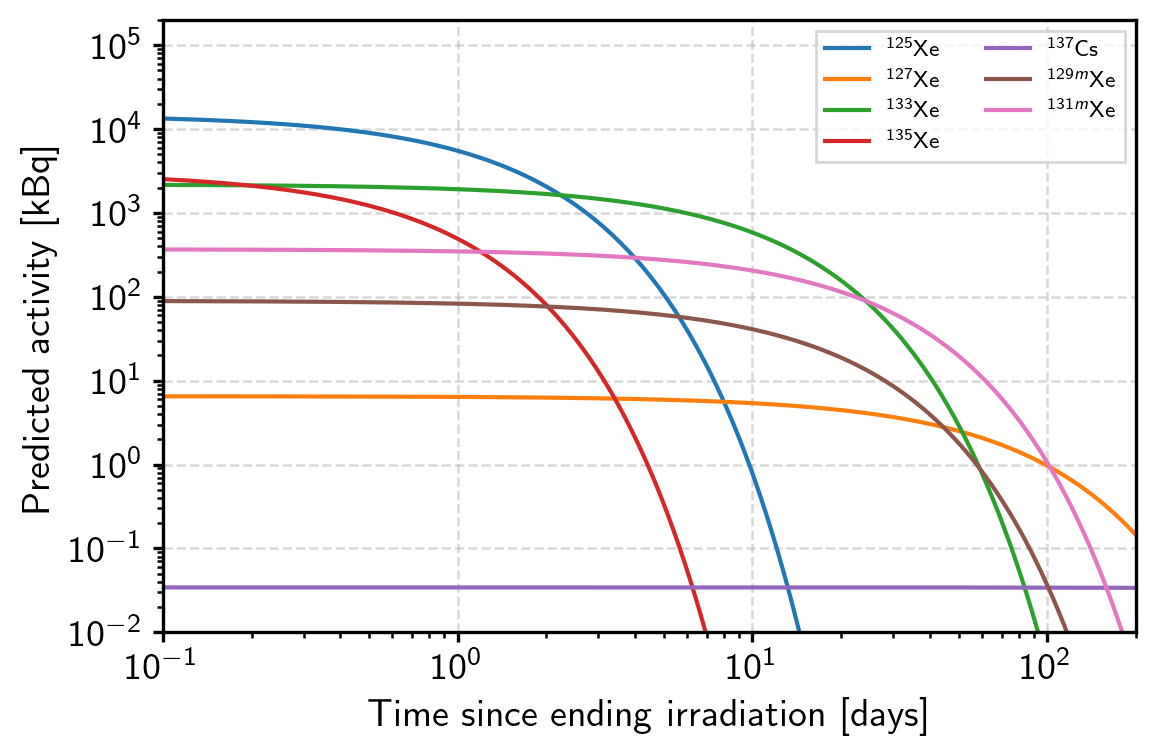

In [29]:
# plot with all isotopes and no empirical scaling
fig, ax = plt.subplots(figsize=(6, 4))
for i,isotope in enumerate(NXe.keys()):
    ax.loglog(times/3600./24., prediction_scale*xenon_mass*np.max(SpecActivityXe[isotope])*np.exp(-times*np.log(2) \
              /HalfLifeXe[isotope])/Bq_per_kBq, \
              lw=1.5, label='$^{' + isotope[2:] + '}$' + isotope[:2])

ax.legend(fontsize=8, ncol=2)
ax.set_ylim([1e-2, 2e5])
ax.set_xlim([1e-1, 2e2])
ax.set_xlabel('Time since ending irradiation [days]')
ax.set_ylabel('Predicted activity [kBq]')
ax.grid()

In [30]:
# measured activities are in kBq
xe_assay_results_ua = pd.DataFrame(columns=['Isotope','Assay Result'])
xe_assay_results_ua = pd.concat([
    xe_assay_results_ua,
    pd.DataFrame([
        {'Isotope': 'Xe127', 'Assay Result': 5720./1000.},
        {'Isotope': 'Xe129m', 'Assay Result': 1.37e5/1000.},
        {'Isotope': 'Xe131m', 'Assay Result': 1.87e5/1000.},
        {'Isotope': 'Cs137', 'Assay Result': 0.314/1000},
        {'Isotope': 'Xe133', 'Assay Result': 2.21e6/1000/2.}
    ])
], ignore_index=True)
print(xe_assay_results_ua.head())

  Isotope  Assay Result
0   Xe127      5.720000
1  Xe129m    137.000000
2  Xe131m    187.000000
3   Cs137      0.000314
4   Xe133   1105.000000


/var/tmp/hardy27/ipykernel_220478/975395186.py:3: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  xe_assay_results_ua = pd.concat([


Isotope: Xe127,  	predicted: 6.53e+00 kBq, measured: 5.72e+00 kBq
Isotope: Xe133,  	predicted: 2.19e+03 kBq, measured: 1.10e+03 kBq
Isotope: Cs137,  	predicted: 3.43e-02 kBq, measured: 3.14e-04 kBq
Isotope: Xe129m,  	predicted: 8.96e+01 kBq, measured: 1.37e+02 kBq
Isotope: Xe131m,  	predicted: 3.69e+02 kBq, measured: 1.87e+02 kBq


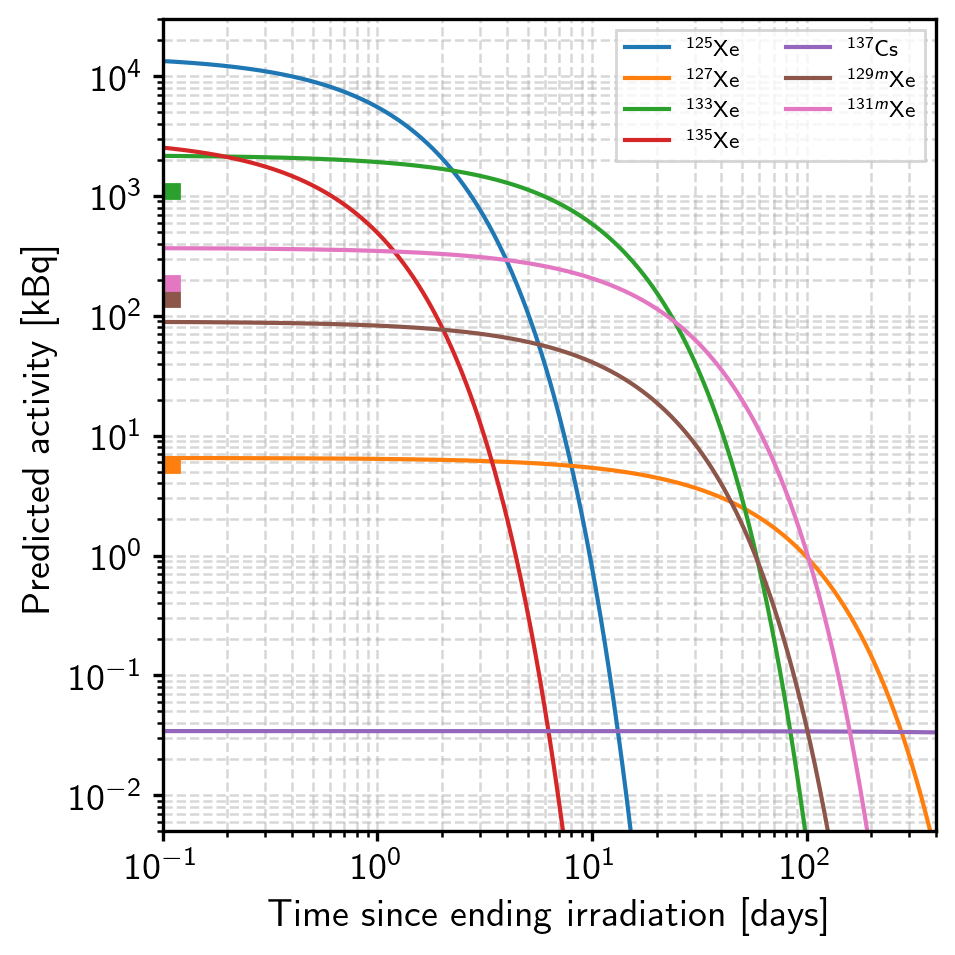

In [31]:
# plot with all isotopes and no empirical scaling
fig, ax = plt.subplots(figsize=(5, 5))
for i,isotope in enumerate(NXe.keys()):

    assay_ua_mask = (xe_assay_results_ua['Isotope']==isotope)

    if len(xe_assay_results_ua['Assay Result'].loc[assay_ua_mask])>0: # and 'Cs137' not in isotope:
        ax.plot(1.1e-1,xe_assay_results_ua['Assay Result'].loc[assay_ua_mask],'s',\
                color=colors[i],markersize=5)#,label='UA assay')
        print('Isotope: {},  \tpredicted: {:.2e} kBq, measured: {:.2e} kBq'.format(isotope, \
              prediction_scale*xenon_mass*np.max(SpecActivityXe[isotope])/Bq_per_kBq, \
              xe_assay_results_ua['Assay Result'].loc[assay_ua_mask].values[0]))

    ax.loglog(times/3600./24., prediction_scale*xenon_mass*np.max(SpecActivityXe[isotope])*np.exp(-times*np.log(2)\
              /HalfLifeXe[isotope])/Bq_per_kBq, color=colors[i], \
              lw=1.5, label='$^{' + isotope[2:] + '}$' + isotope[:2])

ax.legend(fontsize=8, ncol=2)
ax.set_ylim([5e-3, 3e4])
ax.set_xlim([1e-1, 4e2])
ax.set_xlabel('Time since ending irradiation [days]')
ax.set_ylabel('Predicted activity [kBq]')
ax.grid(which='both')

### Save the plot data

In [21]:
# save the data so it can be opened later and plotted for my thesis
with h5py.File('neutron_activation.h5', 'w') as d:
    short_hash = subprocess.check_output(['git', 'rev-parse', '--short', 'HEAD']).decode('ascii').strip()
    git_origin = subprocess.check_output(['git', 'config', '--get', 'remote.origin.url']).decode('ascii').strip()
    
    d.attrs['git_revision_short_hash'] = short_hash
    d.attrs['git_origin'] = git_origin
    d.attrs['creation_timestamp'] = time.time()
    d.attrs['creation_user'] = str(os.environ.get('USER'))
    
    d.create_dataset('mnrc/neutron_energy_bin_centers', data=10**log_bins)
    d.create_dataset('mnrc/neutron_flux_1MW', data=mnrcspec['Flux']/0.25)
    d.create_dataset('crosssections/neutron_energies', data=nucdata['Xe126']['ng'].iloc[:,0])
    d.create_dataset('crosssections/neutron_capture_Xe126', data=nucdata['Xe126']['ng'].iloc[:,1])
    d.create_dataset('activation/time_since_start', data=time_irr)
    d.create_dataset('decay/time_since_end', data=times)
    for isotope in NSteel.keys():
        d.create_dataset('activation/num_atoms_per_g_' + isotope, data=NSteel[isotope])
        d.create_dataset('activation/spec_activity_' + isotope, data=SpecActivitySteel[isotope])
        d.create_dataset('decay/total_activity_' + isotope, data=prediction_scale*bottle_mass*np.max(SpecActivitySteel[isotope])\
                         *np.exp(-times*np.log(2)/HalfLifeSteel[isotope])/Bq_per_kBq)
    for isotope in NXe.keys():
        d.create_dataset('activation/num_atoms_per_g_' + isotope, data=NXe[isotope])
        d.create_dataset('activation/spec_activity_' + isotope, data=SpecActivityXe[isotope])
        d.create_dataset('decay/total_activity_' + isotope, data=prediction_scale*xenon_mass*np.max(SpecActivityXe[isotope])\
                         *np.exp(-times*np.log(2)/HalfLifeXe[isotope])/Bq_per_kBq)
        

In [41]:
SpecActivityXe

{'Xe125': array([0.00000000e+00, 5.04558100e+01, 1.00911594e+02, ...,
        1.00381045e+06, 1.00386039e+06, 1.00391033e+06]),
 'Xe127': array([0.00000000e+00, 2.22030638e-02, 4.44061273e-02, ...,
        4.43950574e+02, 4.43972772e+02, 4.43994971e+02]),
 'Xe133': array([0.00000000e+00, 7.45958990e+00, 1.49191793e+01, ...,
        1.49066847e+05, 1.49074297e+05, 1.49081746e+05]),
 'Xe135': array([0.00000000e+00, 1.04354177e+01, 2.08708256e+01, ...,
        2.06711612e+05, 2.06721851e+05, 2.06732091e+05]),
 'Cs137': array([0.00000000e+00, 1.16640717e-04, 2.33281435e-04, ...,
        2.33246366e+00, 2.33258030e+00, 2.33269694e+00]),
 'Xe129m': array([0.00000000e+00, 2.08984911e-01, 4.17969813e-01, ...,
        4.17737298e+03, 4.17758180e+03, 4.17779061e+03]),
 'Xe131m': array([0.00000000e+00, 3.89943367e-01, 7.79886722e-01, ...,
        7.79532075e+03, 7.79571046e+03, 7.79610016e+03])}